In [1]:
import os, sys
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)

from utils.capsule_migration import CAPSULE_ROOT, capsule_directories
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from utils.plot_utils import combine_pdf_big
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.lick_utils import load_licks, load_licks_video
from utils.combine_tools import apply_qc, to_str_intlike

from open_ephys.analysis import Session
from pathlib import Path
import glob

import json
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from aind_dynamic_foraging_basic_analysis.plot.plot_foraging_session import plot_foraging_session
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
from hdmf_zarr.nwb import NWBZarrIO

import pandas as pd
import pickle
import scipy.stats as stats
from joblib import Parallel, delayed
from multiprocessing import Pool
from functools import partial
import time
import shutil 
from aind_ephys_utils import align
%matplotlib inline

In [3]:
target_folder = str(capsule_directories()['manuscript_fig_dir']) + '/F_spontlicks'
video = True
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

In [4]:
dfs = [pd.read_csv(CAPSULE_ROOT + '/code/data_management/session_assets.csv'),
        pd.read_csv(CAPSULE_ROOT + '/code/data_management/hopkins_session_assets.csv'),
        pd.read_csv(CAPSULE_ROOT + '/code/data_management/hopkins_FP_session_assets.csv')]
df = pd.concat(dfs)
session_list = df['session_id'].values.tolist()
ani_list = [str(session).split('_')[1] for session in session_list if str(session).startswith('behavior')]
session_list = [session for session in session_list if str(session).startswith('behavior')]
ani_session_df = pd.DataFrame({'animal': ani_list, 'session_id': session_list})


In [5]:
from joblib import Parallel, delayed

def compute_switch_stay_lat(session):
    session_tbl = get_session_tbl(session)
    if session_tbl is None:
        return [], [], np.nan, np.nan
    session_tbl_choices = session_tbl[session_tbl['animal_response'] != 2].copy()
    latencies = (
        session_tbl_choices['reward_outcome_time'].values
        - session_tbl_choices['goCue_start_time'].values
    )
    choices = session_tbl_choices['animal_response'].values
    if len(choices) < 2:
        return [], [], np.nan, np.nan
    switch = choices[1:] != choices[:-1]
    switch = np.insert(switch, 0, False)
    switch_lat = latencies[switch]
    stay_lat = latencies[~switch]
    mean_switch_lat = np.mean(switch_lat) if len(switch_lat) > 0 else np.nan
    mean_stay_lat = np.mean(stay_lat) if len(stay_lat) > 0 else np.nan
    return switch_lat.tolist(), stay_lat.tolist(), mean_switch_lat, mean_stay_lat


# ---- PARALLEL EXECUTION ----
results = Parallel(n_jobs=-1)(
    delayed(compute_switch_stay_lat)(session)
    for session in session_list
)


In [6]:

# ---- Combine results ----
all_switch_lat = []
all_stay_lat = []
all_switch_mean = []
all_stay_mean = []
for switch_lat, stay_lat, switch_mean, stay_mean in results:
    all_switch_lat.extend(switch_lat)
    all_stay_lat.extend(stay_lat)
    all_switch_mean.append(switch_mean)
    all_stay_mean.append(stay_mean)

['/root/capsule/scratch/results/manuscript/figures/F_spontlicks/FigureS12d_switch_stay_latency_comparison_scatter.csv']

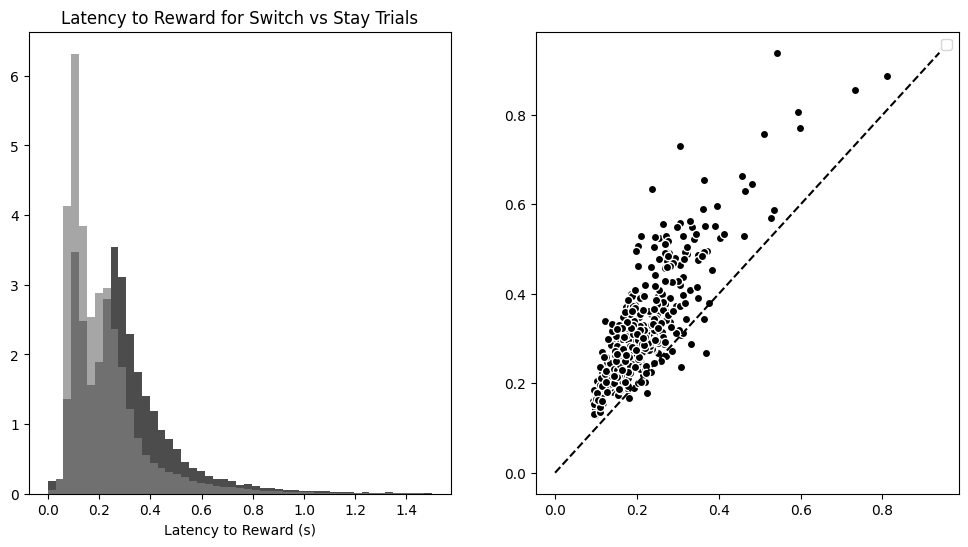

In [7]:
# histogram
fig, axes = plt.subplots(1, 2, figsize=(12,6))
bin_num = 50
edges = np.linspace(0, 1.5, bin_num)
# edges = np.logspace(np.log10(0.01), np.log10(1.5), bin_num)
axes[0].hist(all_switch_lat, bins=edges, alpha=0.7, label='Switch Trials', density=True, color='k')
axes[0].hist(all_stay_lat, bins=edges, alpha=0.7, label='Stay Trials', density=True, color = 'gray')
axes[0].set_xlabel('Latency to Reward (s)')
axes[0].set_label('Density')
axes[0].set_title('Latency to Reward for Switch vs Stay Trials')
plt.legend()
# axes[0].set_xscale('log')

# compare mean latencies
axes[1].scatter(np.array(all_stay_mean), np.array(all_switch_mean), alpha=1, color='k', edgecolor = 'w')
# plot diagonal line
max_val = max(max(all_stay_mean), max(all_switch_mean))
axes[1].plot([0, max_val], [0, max_val], 'k--')
# log scale
# axes[1].set_xscale('log')
# axes[1]

save_panels(fig, target_folder, 'switch_stay_latency_comparison', ['FigureS12d'], exts=('pdf',))
# ---- panel CSVs (rule 7: histogram [d_top] + scatter [d_bottom], both in this cell) ----
save_panel_csv(columns_to_df(switch_latency_s=np.asarray(all_switch_lat), stay_latency_s=np.asarray(all_stay_lat)), target_folder, 'switch_stay_latency_comparison', ['FigureS12d'], plot_type='histogram')
save_panel_csv(columns_to_df(stay_mean_s=np.asarray(all_stay_mean), switch_mean_s=np.asarray(all_switch_mean)), target_folder, 'switch_stay_latency_comparison', ['FigureS12d'], plot_type='scatter')

##FigureS12d##

In [8]:
# load data from all animals and plot summary statistics
capsule_dirs = capsule_directories()
animal_ids = ani_session_df['animal'].unique().tolist()
all_results = []
all_results_model = []
for animal_id in animal_ids:
    save_file = os.path.join(capsule_dirs['manuscript_fig_prep_dir'], 'spontlicks', f'{animal_id}_lick_train_stats_video_{video}.pkl')
    if os.path.exists(save_file):
        with open(save_file, 'rb') as f:
            results = pickle.load(f)
        results['animal_id'] = animal_id
        all_results.append(results)
    else:
        print(f'No lick stats for animal {animal_id}')
    save_file = os.path.join(capsule_dirs['manuscript_fig_prep_dir'], 'spontlicks', f'{animal_id}_lick_in_trial_model_video_{video}.pkl')
    if os.path.exists(save_file):
        with open(save_file, 'rb') as f:
            model_results = pickle.load(f)
        model_results['animal_id'] = animal_id
        all_results_model.append(model_results)
    else:
        print(f'No lick model for animal {animal_id}')

No lick stats for animal 744779
No lick model for animal 744779


In [9]:
# plot ratios.
variables_collect = ['in_out_ratio', 'rl_ratio_out', 'rl_ratio_in', 'rl_ratio_outvsin', 'session_ids', 'rl_ratio_choice', 'rl_ratio_in_reward_choices']
lick_stats_df = pd.DataFrame()
for result in all_results:
    lick_stats_dict = {var: result[var] for var in variables_collect}
    lick_stats_df_curr = pd.DataFrame(lick_stats_dict)
    lick_stats_df = pd.concat([lick_stats_df, lick_stats_df_curr], ignore_index=True)
lick_stats_df['ratio_diff_abs'] = np.abs(lick_stats_df['rl_ratio_out'] - lick_stats_df['rl_ratio_in'])
lick_stats_df['ratio_diff_rwd_abs'] = np.abs(lick_stats_df['rl_ratio_out'] - lick_stats_df['rl_ratio_in_reward_choices'])
variables_collect.append('ratio_diff_abs')
variables_collect.append('ratio_diff_rwd_abs')

In [10]:
lick_stats_df['ratio_diff_rwd'] = np.abs((lick_stats_df['rl_ratio_out'] - lick_stats_df['rl_ratio_in_reward_choices']))

['/root/capsule/scratch/results/manuscript/figures/F_spontlicks/FigureS12h_lick_ratio_in_out_reward_summary_video_True.csv']

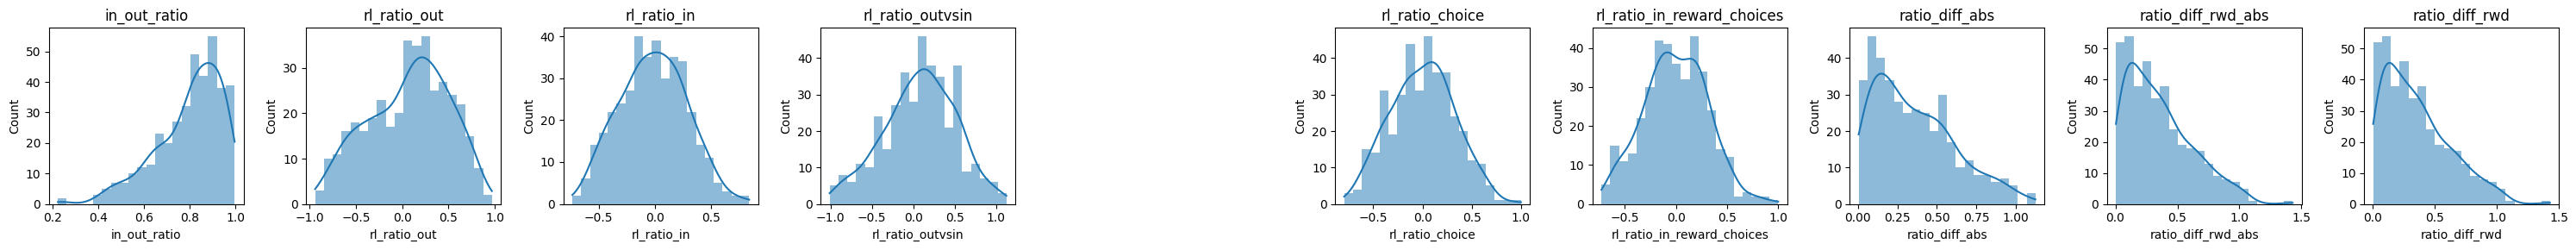

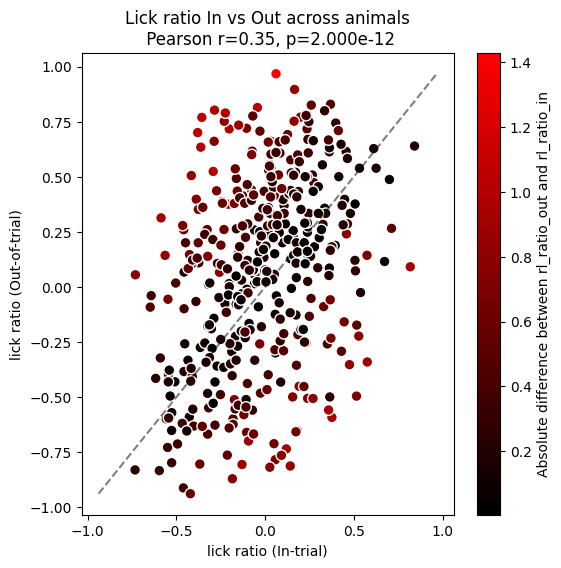

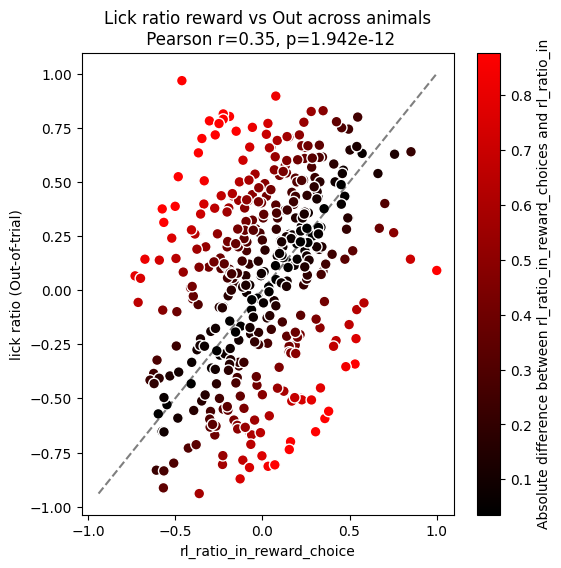

In [11]:

# plot histogram distribution of all of them
fig = plt.figure(figsize=(3*len(lick_stats_df.columns), 3))
gs = gridspec.GridSpec(1, len(lick_stats_df.columns))
for i, var in enumerate(lick_stats_df.columns):
    # if numeric
    if lick_stats_df[var].dtype == 'O':
        continue
    ax = fig.add_subplot(gs[0, i])
    sns.histplot(lick_stats_df[var], ax=ax, kde=True, bins=20, edgecolor='None')
    ax.set_title(var)
plt.tight_layout()
fig.savefig(fname=os.path.join(target_folder, f'lick_stats_histograms_video_{video}.pdf'), dpi=3000)


black_red = LinearSegmentedColormap.from_list(
    "black_red",
    ["black", "red"]
)

# rl ratio out vs in across animals
fig = plt.figure(figsize=(6,6))
g = plt.scatter(lick_stats_df['rl_ratio_in'], lick_stats_df['rl_ratio_out'], alpha=1, s = 60, c=lick_stats_df['ratio_diff_rwd'], cmap=black_red, edgecolor= 'w')
# add diagnonal line
min_v = min(lick_stats_df['rl_ratio_in'].min(), lick_stats_df['rl_ratio_out'].min())
max_v = max(lick_stats_df['rl_ratio_in'].max(), lick_stats_df['rl_ratio_out'].max())
plt.plot([min_v, max_v], [min_v, max_v], 'k--', alpha=0.5)
# colorbar
plt.colorbar(g, label='Absolute difference between rl_ratio_out and rl_ratio_in')
# correlation and p values
corr, p_value = stats.pearsonr(lick_stats_df['rl_ratio_in'], lick_stats_df['rl_ratio_out'])
plt.xlabel('lick ratio (In-trial)')
plt.ylabel('lick ratio (Out-of-trial)')
plt.title(f'Lick ratio In vs Out across animals\n Pearson r={corr:.2f}, p={p_value:.3e}')
fig.savefig(fname=os.path.join(target_folder, f'lick_ratio_in_out_summary_video_{video}.pdf'), dpi=300)

fig = plt.figure(figsize=(6,6))
g = plt.scatter(lick_stats_df['rl_ratio_in_reward_choices'], lick_stats_df['rl_ratio_out'], alpha=1, s = 60, 
                c=lick_stats_df['ratio_diff_rwd'], cmap=black_red, edgecolor= 'w', vmin=lick_stats_df['ratio_diff_rwd'].quantile(0.05), vmax=lick_stats_df['ratio_diff_rwd'].quantile(0.95))
# correlation and p values
min_v = min(lick_stats_df['rl_ratio_in_reward_choices'].min(), lick_stats_df['rl_ratio_out'].min())
max_v = max(lick_stats_df['rl_ratio_in_reward_choices'].max(), lick_stats_df['rl_ratio_out'].max())
plt.plot([min_v, max_v], [min_v, max_v], 'k--', alpha=0.5)
plt.colorbar(g, label='Absolute difference between rl_ratio_in_reward_choices and rl_ratio_in')
corr, p_value = stats.pearsonr(lick_stats_df['rl_ratio_in_reward_choices'], lick_stats_df['rl_ratio_out'])
plt.xlabel('rl_ratio_in_reward_choice')
plt.ylabel('lick ratio (Out-of-trial)')
plt.title(f'Lick ratio reward vs Out across animals\n Pearson r={corr:.2f}, p={p_value:.3e}')

save_panels(fig, target_folder, f'lick_ratio_in_out_reward_summary_video_{video}', ['FigureS12h'], exts=('pdf',), dpi=300)
save_panel_csv(columns_to_df(rl_ratio_in_reward_choices=lick_stats_df['rl_ratio_in_reward_choices'].values, rl_ratio_out=lick_stats_df['rl_ratio_out'].values, ratio_diff_rwd=lick_stats_df['ratio_diff_rwd'].values), target_folder, f'lick_ratio_in_out_reward_summary_video_{video}', ['FigureS12h'])
##FigureS12h##


['/root/capsule/scratch/results/manuscript/figures/F_spontlicks/FigureS12i_lick_ratio_diff_in_reward_choice_vs_in_out_ratio_video_True.csv']

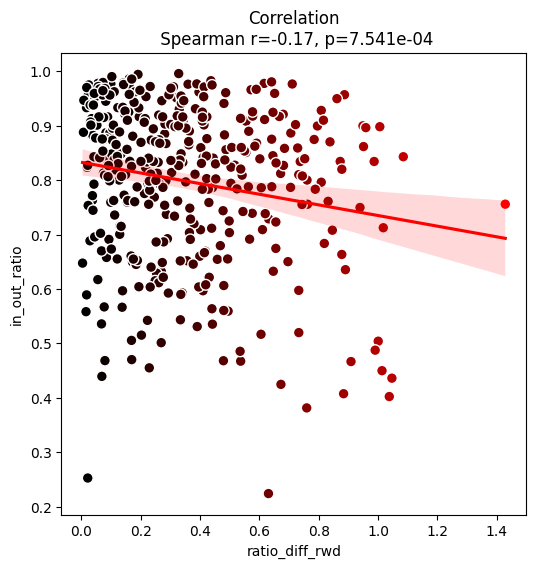

In [12]:
fig = plt.figure(figsize=(6,6))
x = 'ratio_diff_rwd'
y = 'in_out_ratio'
color_code = 'ratio_diff_rwd'
plt.scatter(lick_stats_df[x], lick_stats_df[y], alpha=1, s = 60, c = lick_stats_df[color_code], cmap=black_red, edgecolor= 'w')
# add regression line and confidence interval
sns.regplot(x=lick_stats_df[x], y=lick_stats_df[y], scatter=False, ax=plt.gca(), line_kws={'color': 'red'})
# correlation and p values spearman
corr, p_value = stats.spearmanr(lick_stats_df[x], lick_stats_df[y])
plt.xlabel(x)
plt.ylabel(y)
plt.title(f'Correlation\n Spearman r={corr:.2f}, p={p_value:.3e}')
save_panels(fig, target_folder, f'lick_ratio_diff_in_reward_choice_vs_in_out_ratio_video_{video}', ['FigureS12i'], exts=('pdf',), dpi=300)
save_panel_csv(columns_to_df(ratio_diff_rwd=lick_stats_df['ratio_diff_rwd'].values, in_out_ratio=lick_stats_df['in_out_ratio'].values), target_folder, f'lick_ratio_diff_in_reward_choice_vs_in_out_ratio_video_{video}', ['FigureS12i'])
##FigureS12i##

In [13]:
# load all model results into a list
fit_values = {'post': [], 'pre': [], 'iti': [], 'side_post': [], 'side_pre': [], 'side_iti': []}
for result in all_results_model:
    animal_id = result['animal_id']
    for key in fit_values.keys():
        lm_key = 'lm_' + key
        lm = result[lm_key]
        if lm is not None:
            if key.startswith('side'):
                z_vals = lm.tvalues
                p_vals = lm.pvalues
            else:
                z_vals = lm.tvalues[1:]
                p_vals = lm.pvalues[1:]
            curr_df = pd.DataFrame({'animal_id': animal_id, 'regressor': z_vals.index, 'z_value': z_vals.values, 'model': key, 'p_value': p_vals.values})
            fit_values[key].append(curr_df)
# combine each field into one dataframe
for key in fit_values.keys():
    if len(fit_values[key]) > 0:
        fit_values[key] = pd.concat(fit_values[key])
    else:
        print(f'No model fits for {key}')




['/root/capsule/scratch/results/manuscript/figures/F_spontlicks/FigureS12j_lick_model_coefficients_summary_video_True.csv']

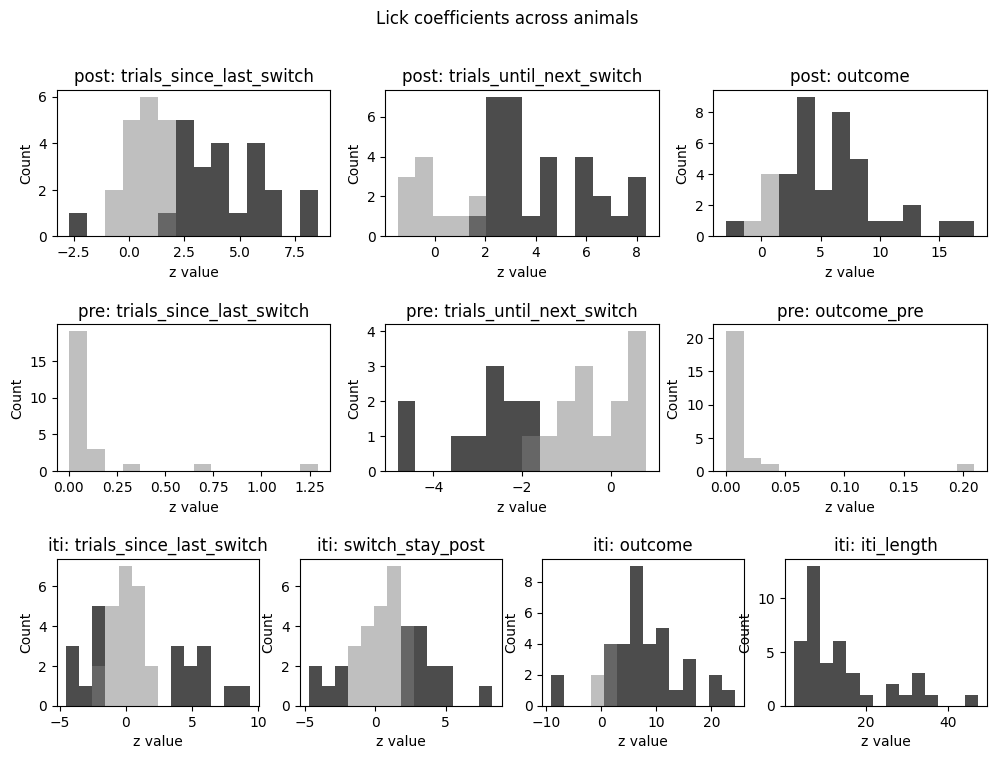

In [14]:
# plot model z values across animals as histograms
# each row is a model (post, pre, iti), each column is a regressor
fig = plt.figure(figsize=(12,8))
model_keys = ['post', 'pre', 'iti']
for row_ind, model_key in enumerate(model_keys):
    model_df = fit_values[model_key]
    regressors = model_df['regressor'].unique().tolist()
    for col_ind, regressor in enumerate(regressors):
        ax = fig.add_subplot(len(model_keys), len(regressors), row_ind*len(regressors) + col_ind + 1)
        reg_df = model_df[model_df['regressor'] == regressor]
        # significant in red, non-significant in gray
        sig_mask = reg_df['p_value'] < 0.05
        bin_edges = np.linspace(np.min(reg_df['z_value']), np.max(reg_df['z_value']), 15)
        ax.hist(reg_df[sig_mask]['z_value'], bins=bin_edges, color='k', alpha=0.7, label='p < 0.05')
        ax.hist(reg_df[~sig_mask]['z_value'], bins=bin_edges, color='gray', alpha=0.5, label='p >= 0.05')

        ax.set_title(f'{model_key}: {regressor}')
        ax.set_xlabel('z value')
        ax.set_ylabel('Count')
plt.suptitle('Lick coefficients across animals')
fig.subplots_adjust(hspace=0.6)
plt.tight_layout()
save_panels(fig, target_folder, f'lick_model_coefficients_summary_video_{video}', ['FigureS12j'], exts=('pdf',), dpi=300)
# ---- panel CSV (rule 8 histogram: z-values per model/regressor, split sig/nonsig) ----
_zc = {}
for _mk in ['post', 'pre', 'iti']:
    _mdf = fit_values[_mk]
    for _reg in _mdf['regressor'].unique().tolist():
        _rdf = _mdf[_mdf['regressor'] == _reg]; _sig = _rdf['p_value'] < 0.05
        _zc[f'{_mk}_{_reg}_sig'] = _rdf[_sig]['z_value'].values
        _zc[f'{_mk}_{_reg}_nonsig'] = _rdf[~_sig]['z_value'].values
save_panel_csv(columns_to_df(**_zc), target_folder, f'lick_model_coefficients_summary_video_{video}', ['FigureS12j'])
##FigureS12j##